# Notebook 04: Evaluation & Explainability

**Project:** Intelligent Code Review Assistant  
**Notebook:** 04
**Input:** `../models/codebert_classifier/`, `../reports/training_results.pkl`, `../data/processed/`  
**Output:** Evaluation plots, SHAP explanations, attention visualizations saved to `../reports/figures/`

---

## Objectives
- Reload the best trained model from Notebook 03
- Deep-dive evaluation beyond basic metrics (error analysis, confidence distribution)
- Explain model predictions using SHAP token-level attribution
- Visualize attention patterns to understand what the model focuses on
- Summarize findings for the final project report

---

## Pipeline
```
training_results.pkl + codebert_classifier/
        ↓
Reload model + results
        ↓
Extended evaluation (error analysis, confidence)
        ↓
SHAP explainability (token-level attributions)
        ↓
Attention visualization
        ↓
Save all figures -> reports/figures/
```

### Install dependencies

In [2]:
# Install all required libraries.
# shap may take 1-2 minutes to install.

!pip install transformers torch scikit-learn pandas numpy tqdm matplotlib seaborn shap -q

print("All packages installed.")

All packages installed.


---
## Section 1: Mount Drive & Configuration

In [3]:
# Mount Google Drive — all project files live here
from google.colab import drive
drive.mount('/content/drive')

import os

BASE = "/content/drive/MyDrive/code_review_project"

# Verify key files exist before proceeding
required = [
    f"{BASE}/reports/training_results.pkl",
    f"{BASE}/data/processed/preprocessing_config.pkl",
    f"{BASE}/data/processed/X_test.npy",
    f"{BASE}/data/processed/y_test.npy",
    f"{BASE}/models/codebert_classifier/config.json",
    f"{BASE}/models/codebert_classifier/classifier_head.pt",
]

print("Checking required files...\n")
all_ok = True
for path in required:
    exists = os.path.exists(path)
    if not exists:
        all_ok = False
    print(f"  {'✅' if exists else '❌'}  {path}")

print(f"\n{'All files found. Ready to proceed.' if all_ok else 'Fix missing files before continuing.'}")

Mounted at /content/drive
Checking required files...

  ✅  /content/drive/MyDrive/code_review_project/reports/training_results.pkl
  ✅  /content/drive/MyDrive/code_review_project/data/processed/preprocessing_config.pkl
  ✅  /content/drive/MyDrive/code_review_project/data/processed/X_test.npy
  ✅  /content/drive/MyDrive/code_review_project/data/processed/y_test.npy
  ✅  /content/drive/MyDrive/code_review_project/models/codebert_classifier/config.json
  ✅  /content/drive/MyDrive/code_review_project/models/codebert_classifier/classifier_head.pt

All files found. Ready to proceed.


In [4]:
CONFIG = {
    "MODEL_NAME"    : "microsoft/codebert-base",
    "MAX_LENGTH"    : 512,
    "BATCH_SIZE"    : 16,
    "DROPOUT"       : 0.1,
    "DATA_DIR"      : f"{BASE}/data/processed/",
    "MODEL_SAVE_DIR": f"{BASE}/models/codebert_classifier/",
    "REPORTS_DIR"   : f"{BASE}/reports/",
    "FIGURES_DIR"   : f"{BASE}/reports/figures/",
}

# Create figures directory if it doesn't exist
os.makedirs(CONFIG["FIGURES_DIR"], exist_ok=True)

import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CONFIG["DEVICE"] = str(DEVICE)

print("Configuration:")
for k, v in CONFIG.items():
    print(f"   {k:<18}: {v}")
print(f"\n   Device: {DEVICE}")
if str(DEVICE) == "cpu":
    print("   No GPU — SHAP will be very slow. Enable T4 GPU in Runtime settings.")

Configuration:
   MODEL_NAME        : microsoft/codebert-base
   MAX_LENGTH        : 512
   BATCH_SIZE        : 16
   DROPOUT           : 0.1
   DATA_DIR          : /content/drive/MyDrive/code_review_project/data/processed/
   MODEL_SAVE_DIR    : /content/drive/MyDrive/code_review_project/models/codebert_classifier/
   REPORTS_DIR       : /content/drive/MyDrive/code_review_project/reports/
   FIGURES_DIR       : /content/drive/MyDrive/code_review_project/reports/figures/
   DEVICE            : cuda

   Device: cuda


---
## Section 2: Imports

In [5]:
# ── Standard library ──────────────────────────────────────────────────────────
import pickle
import warnings
warnings.filterwarnings("ignore")

# ── Data handling ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── PyTorch ────────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ── HuggingFace ────────────────────────────────────────────────────────────────
from transformers import AutoModel, AutoTokenizer

# ── Scikit-learn ───────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve, auc
)

# ── SHAP ───────────────────────────────────────────────────────────────────────
import shap

# ── Visualization ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Progress bar ───────────────────────────────────────────────────────────────
from tqdm.notebook import tqdm

# ── Styling ────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("All libraries imported successfully.")

All libraries imported successfully.


---
## Section 3: Reload Model & Results

Reload the best checkpoint saved by Notebook 03 and the training results pkl.  
No retraining — everything loads from disk.

In [6]:
# Re-define CodeDataset so DataLoader works in this notebook

class CodeDataset(Dataset):
    def __init__(self, data: dict):
        self.input_ids      = data["input_ids"]
        self.attention_mask = data["attention_mask"]
        self.labels         = data["labels"]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels":         self.labels[idx]
        }

    def get_label_distribution(self):
        labels = self.labels.numpy()
        unique, counts = np.unique(labels, return_counts=True)
        return dict(zip(unique, counts))

print("CodeDataset defined.")

CodeDataset defined.


In [26]:
# Re-define the classifier architecture — must match exactly what Notebook 03 saved

class CodeBERTClassifier(nn.Module):
    def __init__(
        self,
        model_name: str    = "microsoft/codebert-base",
        num_labels: int    = 2,
        dropout: float     = 0.1,
        freeze_layers: int = 0
    ):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(
            model_name,
            output_attentions=True,
            attn_implementation="eager"
        )
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.encoder.config.hidden_size, num_labels)
        self._freeze_encoder_layers(freeze_layers)

    def _freeze_encoder_layers(self, n: int):
        for param in self.encoder.embeddings.parameters():
            param.requires_grad = False
        for i, layer in enumerate(self.encoder.encoder.layer):
            if i < n:
                for param in layer.parameters():
                    param.requires_grad = False

    def forward(self, input_ids, attention_mask, labels=None):
        outputs    = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        cls_output = self.dropout(cls_output)
        logits     = self.classifier(cls_output)
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
        return {"loss": loss, "logits": logits}

print("CodeBERTClassifier defined.")

CodeBERTClassifier defined.


In [27]:
# Load preprocessing config and class weights

with open(os.path.join(CONFIG["DATA_DIR"], "preprocessing_config.pkl"), "rb") as f:
    prep_config = pickle.load(f)

class_weights = np.load(os.path.join(CONFIG["DATA_DIR"], "class_weights.npy"))
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

print("Preprocessing config loaded:")
for k, v in prep_config.items():
    print(f"   {k:<18}: {v}")
print(f"\nClass weights: clean={class_weights[0]:.4f}, buggy={class_weights[1]:.4f}")

Preprocessing config loaded:
   model_name        : microsoft/codebert-base
   max_length        : 512
   batch_size        : 16
   random_state      : 42
   num_labels        : 2
   train_size        : 27758
   val_size          : 5949
   test_size         : 5949
   class_weights     : [0.6988418932527694, 1.7572803241326918]
   label_map         : {0: 'clean', 1: 'buggy'}

Class weights: clean=0.6988, buggy=1.7573


In [28]:
# Load the tokenizer saved by Notebook 03

tokenizer = AutoTokenizer.from_pretrained(CONFIG["MODEL_SAVE_DIR"])
print(f"Tokenizer loaded from: {CONFIG['MODEL_SAVE_DIR']}")
print(f"   Vocab size: {tokenizer.vocab_size:,}")

Tokenizer loaded from: /content/drive/MyDrive/code_review_project/models/codebert_classifier/
   Vocab size: 50,265


In [29]:
# Load the best model checkpoint saved by Notebook 03

print("Loading best model checkpoint...")

best_model = CodeBERTClassifier(
    model_name    = CONFIG["MODEL_SAVE_DIR"],
    num_labels    = prep_config["num_labels"],
    dropout       = CONFIG["DROPOUT"],
    freeze_layers = 0    # no freezing for inference
)

best_model.classifier.load_state_dict(
    torch.load(
    os.path.join(CONFIG["MODEL_SAVE_DIR"], "classifier_head.pt"),
    map_location=torch.device('cpu'),
    weights_only=True
    )
)

best_model = best_model.to(DEVICE)
best_model.eval()

print(f"Model loaded and moved to: {DEVICE}")

Loading best model checkpoint...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model loaded and moved to: cuda


In [30]:
# Load training results saved by Notebook 03

results_path = os.path.join(CONFIG["REPORTS_DIR"], "training_results.pkl")
with open(results_path, "rb") as f:
    results = pickle.load(f)

history      = results["history"]
test_preds   = results["test_preds"]
test_labels  = results["test_labels"]
test_probs   = results["test_probs"]
best_epoch   = results["best_epoch"]
best_val_f1  = results["best_val_f1"]

print("Training results loaded.")
print(f"\n   Best epoch  : {best_epoch}")
print(f"   Best val F1 : {best_val_f1:.4f}")
print(f"   Test metrics: {results['test_metrics']}")

Training results loaded.

   Best epoch  : 3
   Best val F1 : 0.6572
   Test metrics: {'loss': 0.4759760838682934, 'accuracy': 0.7423096318709027, 'precision': 0.5303260045489007, 'recall': 0.826343768458358, 'f1': 0.6460401754791041, 'roc_auc': np.float64(0.8519386410873611)}


In [31]:
# Load raw test code strings (saved by Notebook 02, needed for explainability)

X_test = np.load(os.path.join(CONFIG["DATA_DIR"], "X_test.npy"), allow_pickle=True)
y_test = np.load(os.path.join(CONFIG["DATA_DIR"], "y_test.npy"), allow_pickle=True)

print(f"X_test loaded: {len(X_test):,} samples")
print(f"y_test loaded: {len(y_test):,} samples")
print(f"   Clean (0): {(y_test == 0).sum():,}")
print(f"   Buggy (1): {(y_test == 1).sum():,}")

X_test loaded: 5,949 samples
y_test loaded: 5,949 samples
   Clean (0): 4,256
   Buggy (1): 1,693


In [32]:
# Load test tensors and rebuild DataLoader for re-evaluation

test_data    = torch.load(os.path.join(CONFIG["DATA_DIR"], "test.pt"), weights_only=True)
test_dataset = CodeDataset(test_data)
test_loader  = DataLoader(
    test_dataset,
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=False,
    num_workers=0
)

print(f"Test DataLoader ready: {len(test_dataset):,} samples, {len(test_loader)} batches")

Test DataLoader ready: 5,949 samples, 372 batches


---
## Section 4: Reproduce Test Metrics

Re-run evaluation on the test set to confirm results match Notebook 03.  
This also gives us prediction probabilities for deeper analysis.

In [33]:
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits  = outputs["logits"]

            loss = loss_fn(logits, labels)
            total_loss += loss.item()

            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    return {
        "loss"      : total_loss / len(loader),
        "accuracy"  : accuracy_score(all_labels, all_preds),
        "precision" : precision_score(all_labels, all_preds, zero_division=0),
        "recall"    : recall_score(all_labels, all_preds, zero_division=0),
        "f1"        : f1_score(all_labels, all_preds, zero_division=0),
        "roc_auc"   : roc_auc_score(all_labels, all_probs),
        "all_preds" : all_preds,
        "all_labels": all_labels,
        "all_probs" : all_probs
    }

print("evaluate function defined.")

evaluate function defined.


In [34]:
print("Re-evaluating on test set...\n")
test_metrics = evaluate(best_model, test_loader, loss_fn, DEVICE)

print("=" * 55)
print("  FINAL TEST SET RESULTS")
print("=" * 55)
print(f"  Loss      : {test_metrics['loss']:.4f}")
print(f"  Accuracy  : {test_metrics['accuracy']:.4f}  ({test_metrics['accuracy']*100:.1f}%)")
print(f"  Precision : {test_metrics['precision']:.4f}")
print(f"  Recall    : {test_metrics['recall']:.4f}")
print(f"  F1 Score  : {test_metrics['f1']:.4f}")
print(f"  ROC-AUC   : {test_metrics['roc_auc']:.4f}")
print("=" * 55)

print("\nClassification report:")
print(classification_report(
    test_metrics["all_labels"],
    test_metrics["all_preds"],
    target_names=["Clean (0)", "Buggy (1)"]
))

Re-evaluating on test set...



Evaluating:   0%|          | 0/372 [00:00<?, ?it/s]

  FINAL TEST SET RESULTS
  Loss      : 0.4760
  Accuracy  : 0.7423  (74.2%)
  Precision : 0.5303
  Recall    : 0.8263
  F1 Score  : 0.6460
  ROC-AUC   : 0.8519

Classification report:
              precision    recall  f1-score   support

   Clean (0)       0.91      0.71      0.80      4256
   Buggy (1)       0.53      0.83      0.65      1693

    accuracy                           0.74      5949
   macro avg       0.72      0.77      0.72      5949
weighted avg       0.80      0.74      0.75      5949



---
## Section 5: Training Curves

Reproduce training history plots from Notebook 03 results.

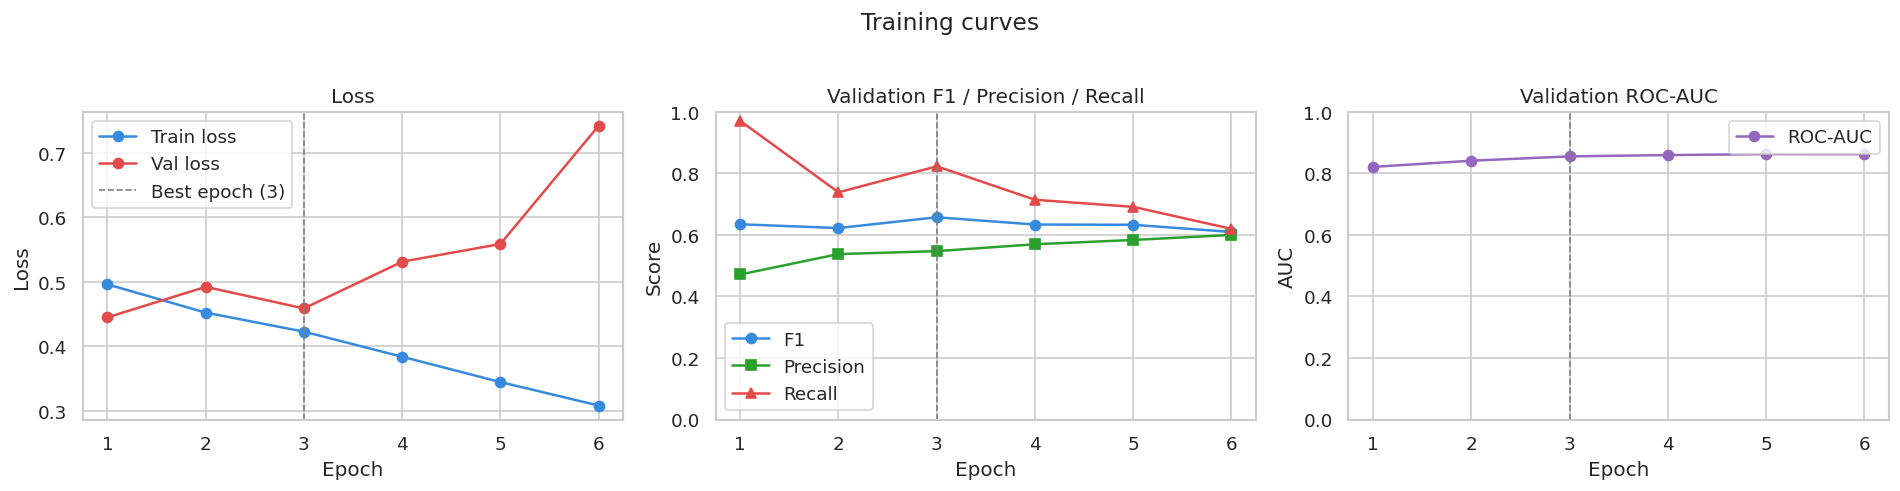

Saved: 10_training_curves.png


In [35]:
epochs_run = len(history["train_loss"])
x = range(1, epochs_run + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss curves
axes[0].plot(x, history["train_loss"], label="Train loss", color="#378ADD", marker="o")
axes[0].plot(x, history["val_loss"],   label="Val loss",   color="#E24B4A", marker="o")
axes[0].axvline(best_epoch, color="gray", linestyle="--", linewidth=1,
                label=f"Best epoch ({best_epoch})")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# F1 / Precision / Recall
axes[1].plot(x, history["val_f1"],        label="F1",        color="#378ADD", marker="o")
axes[1].plot(x, history["val_precision"], label="Precision", color="#2CA02C", marker="s")
axes[1].plot(x, history["val_recall"],    label="Recall",    color="#E24B4A", marker="^")
axes[1].axvline(best_epoch, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Validation F1 / Precision / Recall")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1)
axes[1].legend()

# ROC-AUC
axes[2].plot(x, history["val_roc_auc"], label="ROC-AUC", color="#9467BD", marker="o")
axes[2].axvline(best_epoch, color="gray", linestyle="--", linewidth=1)
axes[2].set_title("Validation ROC-AUC")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("AUC")
axes[2].set_ylim(0, 1)
axes[2].legend()

plt.suptitle("Training curves", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["FIGURES_DIR"], "10_training_curves.png"), bbox_inches="tight")
plt.show()
print("Saved: 10_training_curves.png")

---
## Section 6: Evaluation Plots

Full evaluation of the best model on the test set:
1. Confusion matrix (raw counts)
2. Normalized confusion matrix
3. ROC curve
4. Precision-Recall curve

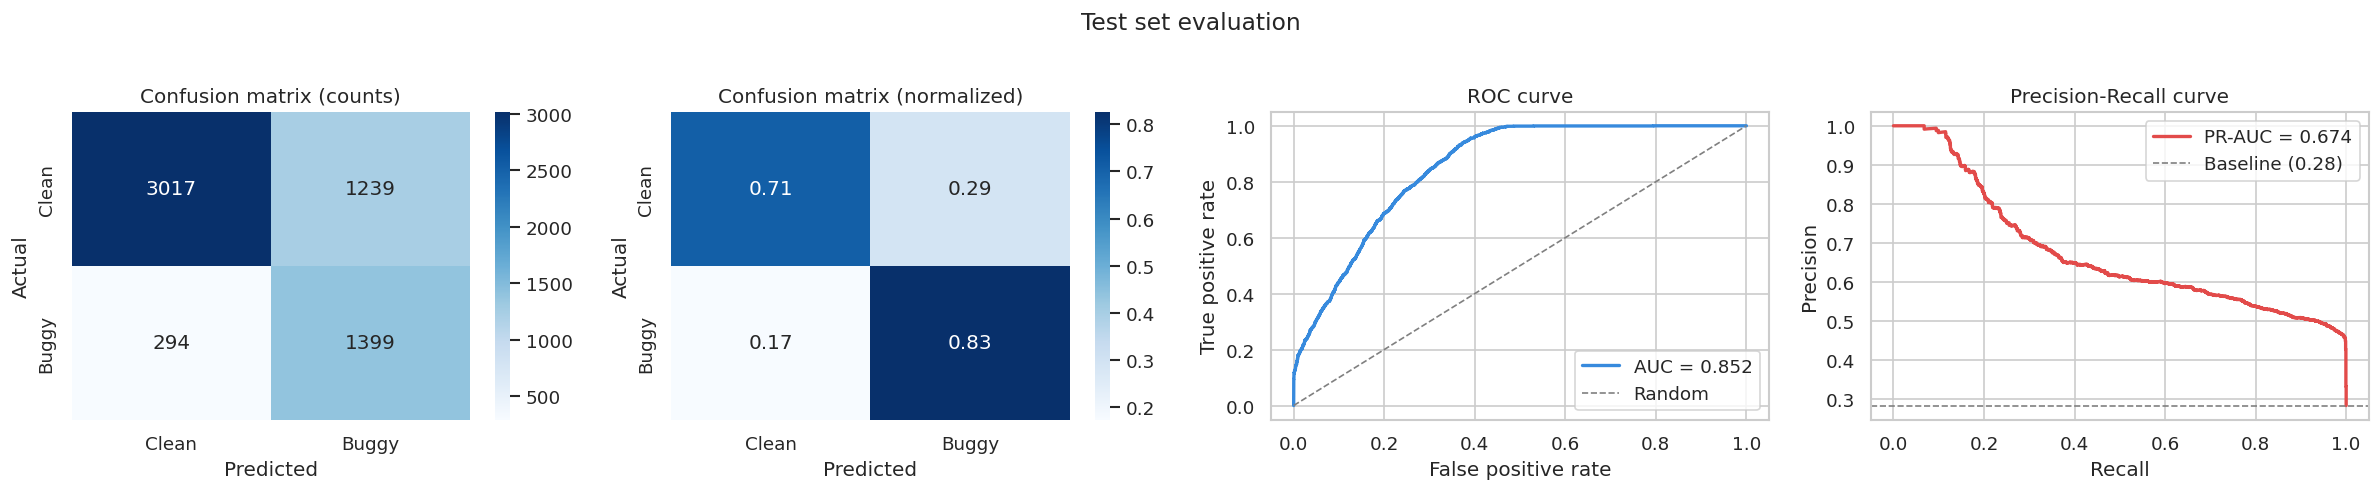

Saved: 11_test_evaluation.png


In [36]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Confusion matrix — raw counts
cm = confusion_matrix(test_metrics["all_labels"], test_metrics["all_preds"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Clean", "Buggy"],
            yticklabels=["Clean", "Buggy"])
axes[0].set_title("Confusion matrix (counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Confusion matrix — normalized
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=axes[1],
            xticklabels=["Clean", "Buggy"],
            yticklabels=["Clean", "Buggy"])
axes[1].set_title("Confusion matrix (normalized)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# ROC curve
fpr, tpr, _ = roc_curve(test_metrics["all_labels"], test_metrics["all_probs"])
roc_auc_val = auc(fpr, tpr)
axes[2].plot(fpr, tpr, color="#378ADD", lw=2, label=f"AUC = {roc_auc_val:.3f}")
axes[2].plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1, label="Random")
axes[2].set_title("ROC curve")
axes[2].set_xlabel("False positive rate")
axes[2].set_ylabel("True positive rate")
axes[2].legend()

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(test_metrics["all_labels"], test_metrics["all_probs"])
pr_auc = auc(rec, prec)
axes[3].plot(rec, prec, color="#E24B4A", lw=2, label=f"PR-AUC = {pr_auc:.3f}")
baseline = test_metrics["all_labels"].mean()
axes[3].axhline(baseline, color="gray", linestyle="--", lw=1,
                label=f"Baseline ({baseline:.2f})")
axes[3].set_title("Precision-Recall curve")
axes[3].set_xlabel("Recall")
axes[3].set_ylabel("Precision")
axes[3].legend()

plt.suptitle("Test set evaluation", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["FIGURES_DIR"], "11_test_evaluation.png"), bbox_inches="tight")
plt.show()
print("Saved: 11_test_evaluation.png")

---
## Section 7: Confidence Distribution Analysis

Analyze how confident the model is across correct and incorrect predictions.  
A well-calibrated model should be:
- High confidence on correct predictions
- Low confidence (near 0.5) on incorrect predictions

This plot reveals whether the model is overconfident on its mistakes.

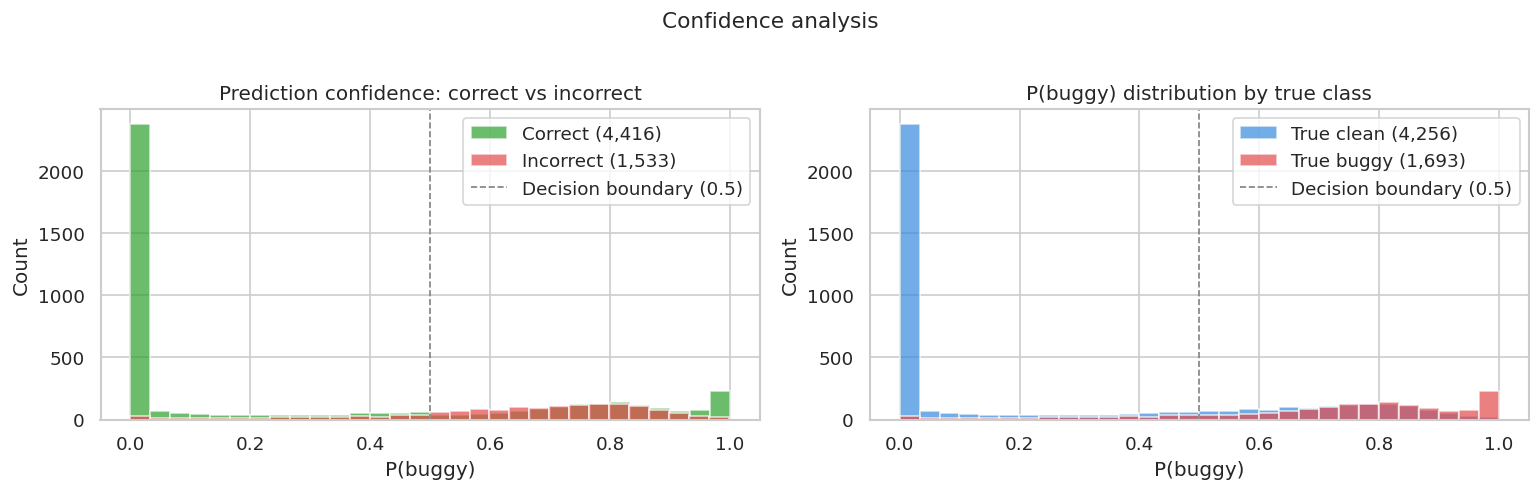

Saved: 12_confidence_distribution.png


In [37]:
all_preds  = test_metrics["all_preds"]
all_labels = test_metrics["all_labels"]
all_probs  = test_metrics["all_probs"]

correct_probs   = all_probs[all_preds == all_labels]
incorrect_probs = all_probs[all_preds != all_labels]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confidence distribution: correct vs incorrect
axes[0].hist(correct_probs,   bins=30, alpha=0.7, color="#2CA02C", label=f"Correct ({len(correct_probs):,})")
axes[0].hist(incorrect_probs, bins=30, alpha=0.7, color="#E24B4A", label=f"Incorrect ({len(incorrect_probs):,})")
axes[0].axvline(0.5, color="gray", linestyle="--", lw=1, label="Decision boundary (0.5)")
axes[0].set_title("Prediction confidence: correct vs incorrect")
axes[0].set_xlabel("P(buggy)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Confidence by true class
clean_probs = all_probs[all_labels == 0]
buggy_probs = all_probs[all_labels == 1]

axes[1].hist(clean_probs, bins=30, alpha=0.7, color="#378ADD", label=f"True clean ({len(clean_probs):,})")
axes[1].hist(buggy_probs, bins=30, alpha=0.7, color="#E24B4A", label=f"True buggy ({len(buggy_probs):,})")
axes[1].axvline(0.5, color="gray", linestyle="--", lw=1, label="Decision boundary (0.5)")
axes[1].set_title("P(buggy) distribution by true class")
axes[1].set_xlabel("P(buggy)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.suptitle("Confidence analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["FIGURES_DIR"], "12_confidence_distribution.png"), bbox_inches="tight")
plt.show()
print("Saved: 12_confidence_distribution.png")

---
## Section 8: Error Analysis

Examine the samples the model got wrong.  
Focus on:
- False Negatives (buggy code predicted as clean) — most dangerous in production
- False Positives (clean code predicted as buggy) — annoying but not dangerous
- What confidence level the model had on these mistakes

In [38]:
# Build a results DataFrame for error analysis
results_df = pd.DataFrame({
    "code"      : X_test,
    "true_label": all_labels,
    "pred_label": all_preds,
    "prob_buggy": all_probs,
    "correct"   : all_preds == all_labels
})

results_df["error_type"] = "correct"
results_df.loc[(results_df["true_label"] == 1) & (results_df["pred_label"] == 0), "error_type"] = "false_negative"
results_df.loc[(results_df["true_label"] == 0) & (results_df["pred_label"] == 1), "error_type"] = "false_positive"

print("Results DataFrame built.")
print(f"\n{'Error type':<20} {'Count':>8} {'%':>8}")
print("─" * 38)
for etype, count in results_df["error_type"].value_counts().items():
    pct = count / len(results_df) * 100
    print(f"{etype:<20} {count:>8,} {pct:>7.1f}%")

print(f"\nTotal test samples: {len(results_df):,}")

Results DataFrame built.

Error type              Count        %
──────────────────────────────────────
correct                 4,416    74.2%
false_positive          1,239    20.8%
false_negative            294     4.9%

Total test samples: 5,949


In [39]:
# Show top 5 most confident FALSE NEGATIVES
# These are buggy samples the model was very sure were clean — most dangerous errors

fn_df = results_df[results_df["error_type"] == "false_negative"].sort_values("prob_buggy")

print(f"FALSE NEGATIVES (buggy predicted as clean): {len(fn_df)}\n")
print("Top 5 most confident false negatives (model was most sure these were clean):\n")

for i, (_, row) in enumerate(fn_df.head(5).iterrows()):
    print(f"--- Sample {i+1}  |  P(buggy) = {row['prob_buggy']:.4f} ---")
    print(row["code"][:300])
    print()

FALSE NEGATIVES (buggy predicted as clean): 294

Top 5 most confident false negatives (model was most sure these were clean):

--- Sample 1  |  P(buggy) = 0.0000 ---
import statistics

def mode(input_list):  # Defining function "mode."
    2
    >>> input_list = [2, 3, 4, 5, 3, 4, 2, 5, 2, 2, 4, 2, 2, 2]
    >>> mode(input_list) == statistics.mode(input_list)
    True
    # Copying input_list to check with the index number later.
    check_list = input_list.copy

--- Sample 2  |  P(buggy) = 0.0000 ---
Basic authentication using an API password is deprecated and will soon no longer work.
Visit https://developer.github.com/changes/2020-02-14-deprecating-password-auth
for more information around suggested workarounds and removal dates.
"""
_GITHUB_API = "https://api.github.com/user"
def fetch_github

--- Sample 3  |  P(buggy) = 0.0014 ---
static void vp8_h_loop_filter_simple_c(uint8_t *dst, ptrdiff_t stride, int flim)

{

    int i;

    for (i = 0; i < 16; i++)

        if (simple_limit(

In [40]:
# Show top 5 most confident FALSE POSITIVES
# These are clean samples the model was very sure were buggy

fp_df = results_df[results_df["error_type"] == "false_positive"].sort_values("prob_buggy", ascending=False)

print(f"FALSE POSITIVES (clean predicted as buggy): {len(fp_df)}\n")
print("Top 5 most confident false positives (model was most sure these were buggy):\n")

for i, (_, row) in enumerate(fp_df.head(5).iterrows()):
    print(f"--- Sample {i+1}  |  P(buggy) = {row['prob_buggy']:.4f} ---")
    print(row["code"][:300])
    print()

FALSE POSITIVES (clean predicted as buggy): 1239

Top 5 most confident false positives (model was most sure these were buggy):

--- Sample 1  |  P(buggy) = 0.9985 ---
int ff_socket_nonblock(int socket, int enable)

{

#ifdef __MINGW32__

   return ioctlsocket(socket, FIONBIO, &enable);

#else

   if (enable)

      return fcntl(socket, F_SETFL, fcntl(socket, F_GETFL) | O_NONBLOCK);

   else

      return fcntl(socket, F_SETFL, fcntl(socket, F_GETFL) & ~O_NONBLOCK

--- Sample 2  |  P(buggy) = 0.9941 ---
static inline void RENAME(bgr24ToUV_half)(uint8_t *dstU, uint8_t *dstV, const uint8_t *src1, const uint8_t *src2, long width, uint32_t *unused)

{

    int i;

    for (i=0; i<width; i++) {

        int b= src1[6*i + 0] + src1[6*i + 3];

        int g= src1[6*i + 1] + src1[6*i + 4];

        int r= 

--- Sample 3  |  P(buggy) = 0.9922 ---
static void armv7m_nvic_class_init(ObjectClass *klass, void *data)

{

    NVICClass *nc = NVIC_CLASS(klass);

    DeviceClass *dc = DEVICE_CLASS(klass

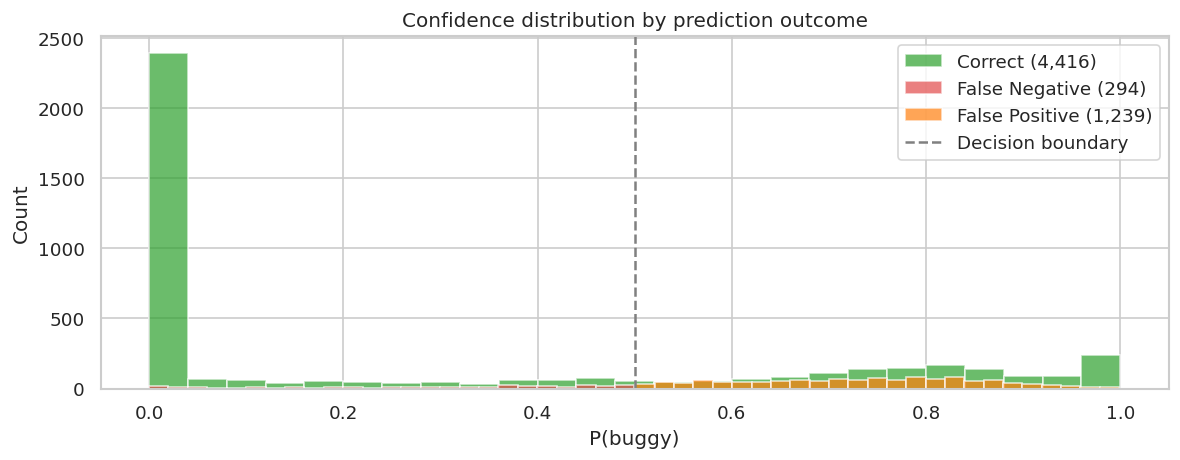

Saved: 13_error_analysis.png


In [41]:
# Confidence distribution broken down by error type

fig, ax = plt.subplots(figsize=(10, 4))

colors = {"correct": "#2CA02C", "false_negative": "#E24B4A", "false_positive": "#FF7F0E"}
labels_map = {
    "correct"        : f"Correct ({results_df['error_type'].eq('correct').sum():,})",
    "false_negative" : f"False Negative ({len(fn_df):,})",
    "false_positive" : f"False Positive ({len(fp_df):,})"
}

for etype, color in colors.items():
    subset = results_df[results_df["error_type"] == etype]["prob_buggy"]
    if len(subset) > 0:
        ax.hist(subset, bins=25, alpha=0.7, color=color, label=labels_map[etype])

ax.axvline(0.5, color="gray", linestyle="--", lw=1.5, label="Decision boundary")
ax.set_title("Confidence distribution by prediction outcome")
ax.set_xlabel("P(buggy)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["FIGURES_DIR"], "13_error_analysis.png"), bbox_inches="tight")
plt.show()
print("Saved: 13_error_analysis.png")

---
## Section 9: Attention Visualization

Visualize which tokens the model's [CLS] head attends to most strongly.  
Attention weights show what the model "looks at" when making a prediction.

Note: Attention ≠ importance (a token attended to doesn't mean it caused the prediction),  
but it gives useful intuition about model behavior.

In [42]:
def get_attention_weights(model, tokenizer, code, device, max_length=512):
    """
    Run a forward pass with output_attentions=True and return:
    - tokens    : list of token strings
    - attention : mean CLS attention over all heads in the last layer
    - pred      : predicted label (0 or 1)
    - prob      : P(buggy)
    """
    model.eval()
    inputs = tokenizer(
        code,
        return_tensors="pt",
        max_length=max_length,
        truncation=True,
        padding="max_length"
    ).to(device)

    with torch.no_grad():
        # Get encoder outputs with attention weights
        encoder_outputs = model.encoder(
            input_ids      = inputs["input_ids"],
            attention_mask = inputs["attention_mask"],
            output_attentions=True
        )
        # Classification
        cls_hidden = encoder_outputs.last_hidden_state[:, 0, :]
        cls_hidden = model.dropout(cls_hidden)
        logits     = model.classifier(cls_hidden)
        probs      = torch.softmax(logits, dim=1)
        pred       = torch.argmax(logits, dim=1).item()
        prob_buggy = probs[0, 1].item()

    # Last layer attention: (1, num_heads, seq_len, seq_len)
    last_attn  = encoder_outputs.attentions[-1]
    # Average over heads, take CLS row → attention over all tokens
    avg_attn   = last_attn[0].mean(dim=0)[0]   # (seq_len,)

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    mask   = inputs["attention_mask"][0].cpu().numpy()

    # Keep only real tokens (not padding)
    real_tokens = [(t, a.item()) for t, a, m in zip(tokens, avg_attn.cpu(), mask) if m == 1]

    return real_tokens, pred, prob_buggy


print("get_attention_weights function defined.")

get_attention_weights function defined.


In [43]:
def plot_attention(tokens_weights, pred, prob_buggy, title="Attention visualization", save_path=None):
    """
    Plot a horizontal bar chart of token attention weights.
    Top 30 tokens shown, sorted by attention descending.
    Padding and special tokens excluded.
    """
    # Filter out special tokens and limit to top 30
    filtered = [(t, w) for t, w in tokens_weights
                if t not in ["<s>", "</s>", "<pad>", "<unk>"]]
    filtered = sorted(filtered, key=lambda x: x[1], reverse=True)[:30]

    tokens  = [t for t, _ in filtered]
    weights = [w for _, w in filtered]

    fig, ax = plt.subplots(figsize=(10, max(4, len(tokens) * 0.32)))
    colors  = ["#E24B4A" if pred == 1 else "#378ADD"] * len(tokens)
    bars    = ax.barh(range(len(tokens)), weights, color=colors, alpha=0.85)

    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Attention weight (CLS, last layer, avg heads)")
    ax.set_title(f"{title}\nPrediction: {'Buggy' if pred==1 else 'Clean'}  |  P(buggy) = {prob_buggy:.4f}")

    patch = mpatches.Patch(
        color="#E24B4A" if pred == 1 else "#378ADD",
        label="Buggy" if pred == 1 else "Clean"
    )
    ax.legend(handles=[patch])
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()


print("plot_attention function defined.")

plot_attention function defined.


Sample index : 1
True label   : Buggy (1)
Prediction   : Buggy
P(buggy)     : 0.8599

Code (first 300 chars):
static const uint8_t *pcx_rle_decode(const uint8_t *src,

                                     const uint8_t *end,

                                     uint8_t *dst,

                                     unsigned int bytes_per_scanline,

                                     int compressed)

{

    
Saved: /content/drive/MyDrive/code_review_project/reports/figures/14_attention_true_positive.png


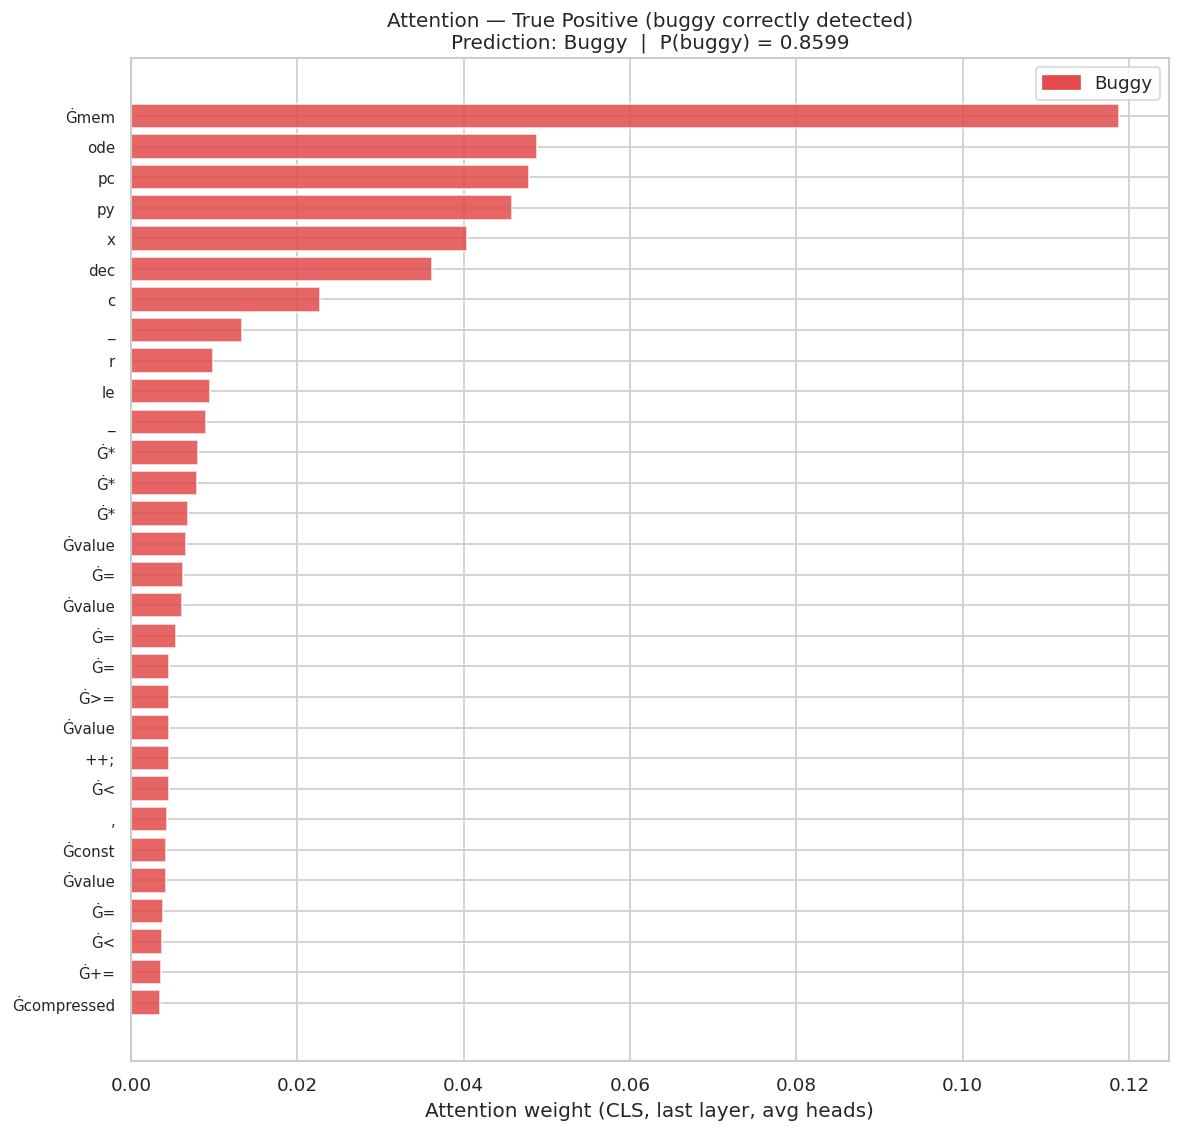

In [44]:
# Visualize attention for one TRUE POSITIVE (buggy correctly predicted as buggy)

tp_idx = results_df[
    (results_df["true_label"] == 1) & (results_df["pred_label"] == 1)
].index[0]

code_sample = X_test[tp_idx]
tokens_weights, pred, prob = get_attention_weights(best_model, tokenizer, code_sample, DEVICE)

print(f"Sample index : {tp_idx}")
print(f"True label   : Buggy (1)")
print(f"Prediction   : {'Buggy' if pred==1 else 'Clean'}")
print(f"P(buggy)     : {prob:.4f}")
print(f"\nCode (first 300 chars):\n{code_sample[:300]}")

plot_attention(
    tokens_weights, pred, prob,
    title="Attention — True Positive (buggy correctly detected)",
    save_path=os.path.join(CONFIG["FIGURES_DIR"], "14_attention_true_positive.png")
)

Sample index : 4508
True label   : Buggy (1)
Prediction   : Clean  ← MISSED
P(buggy)     : 0.0000

Code (first 300 chars):
import statistics

def mode(input_list):  # Defining function "mode."
    2
    >>> input_list = [2, 3, 4, 5, 3, 4, 2, 5, 2, 2, 4, 2, 2, 2]
    >>> mode(input_list) == statistics.mode(input_list)
    True
    # Copying input_list to check with the index number later.
    check_list = input_list.copy
Saved: /content/drive/MyDrive/code_review_project/reports/figures/15_attention_false_negative.png


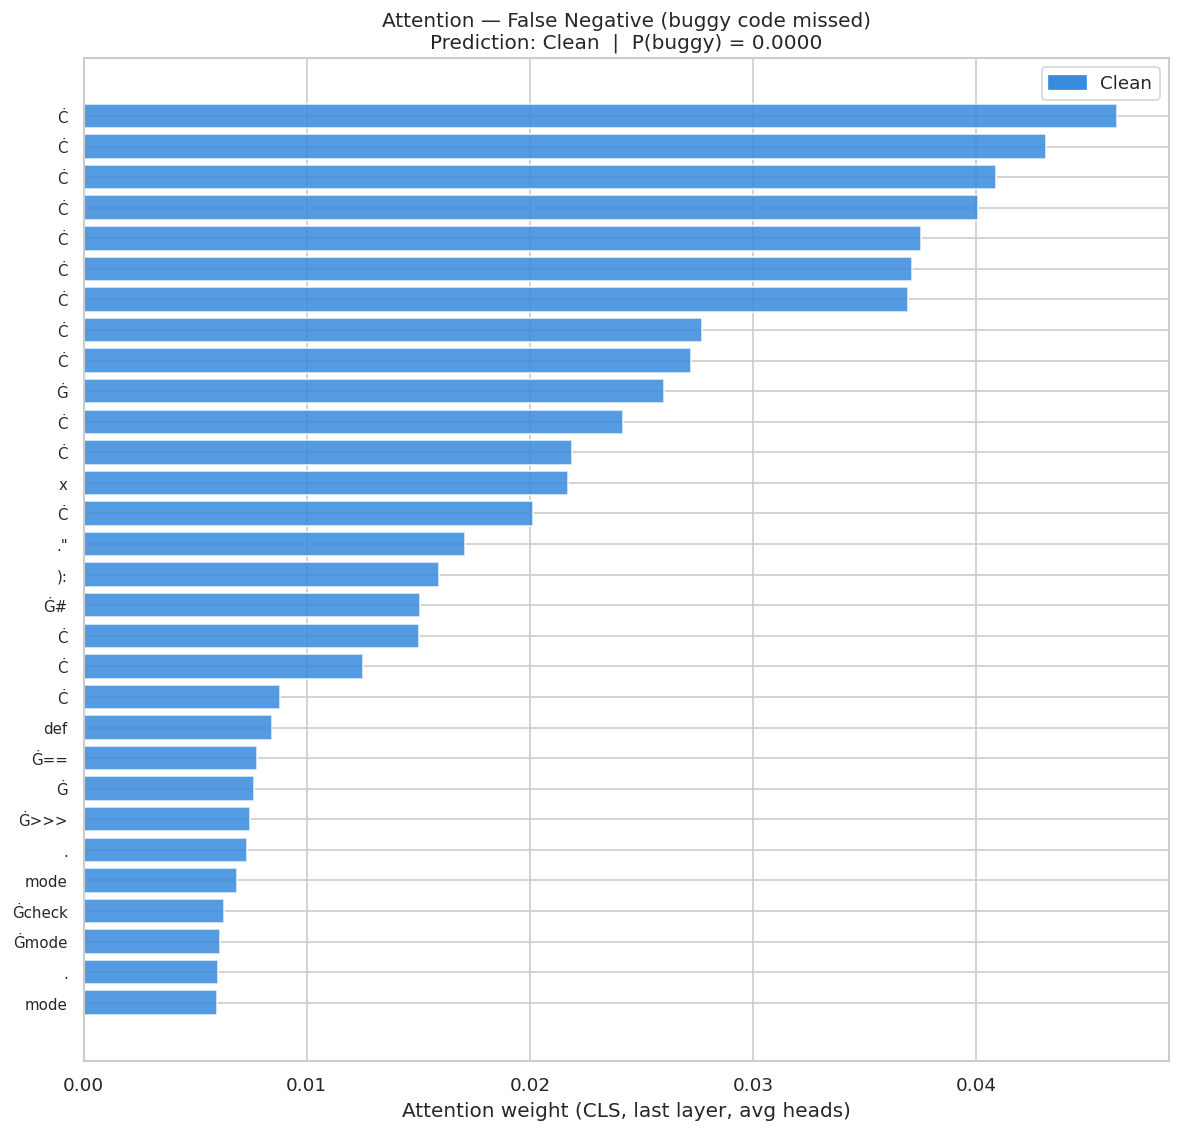

In [45]:
# Visualize attention for one FALSE NEGATIVE (buggy missed — predicted clean)

if len(fn_df) > 0:
    fn_idx = fn_df.index[0]
    code_sample = X_test[fn_idx]
    tokens_weights, pred, prob = get_attention_weights(best_model, tokenizer, code_sample, DEVICE)

    print(f"Sample index : {fn_idx}")
    print(f"True label   : Buggy (1)")
    print(f"Prediction   : {'Buggy' if pred==1 else 'Clean'}  ← MISSED")
    print(f"P(buggy)     : {prob:.4f}")
    print(f"\nCode (first 300 chars):\n{code_sample[:300]}")

    plot_attention(
        tokens_weights, pred, prob,
        title="Attention — False Negative (buggy code missed)",
        save_path=os.path.join(CONFIG["FIGURES_DIR"], "15_attention_false_negative.png")
    )
else:
    print("No false negatives in test set — model caught all bugs!")

Sample index : 0
True label   : Clean (0)
Prediction   : Clean
P(buggy)     : 0.0000

Code (first 300 chars):
def question_field(self, move_x, move_y):
        """Question a grid by given position."""
        field_status = self.info_map[move_y, move_x]

        # a questioned or undiscovered field
        if field_status != 10 and (field_status == 9 or field_status == 11):
            self.info_map[move_y,
Saved: /content/drive/MyDrive/code_review_project/reports/figures/16_attention_true_negative.png


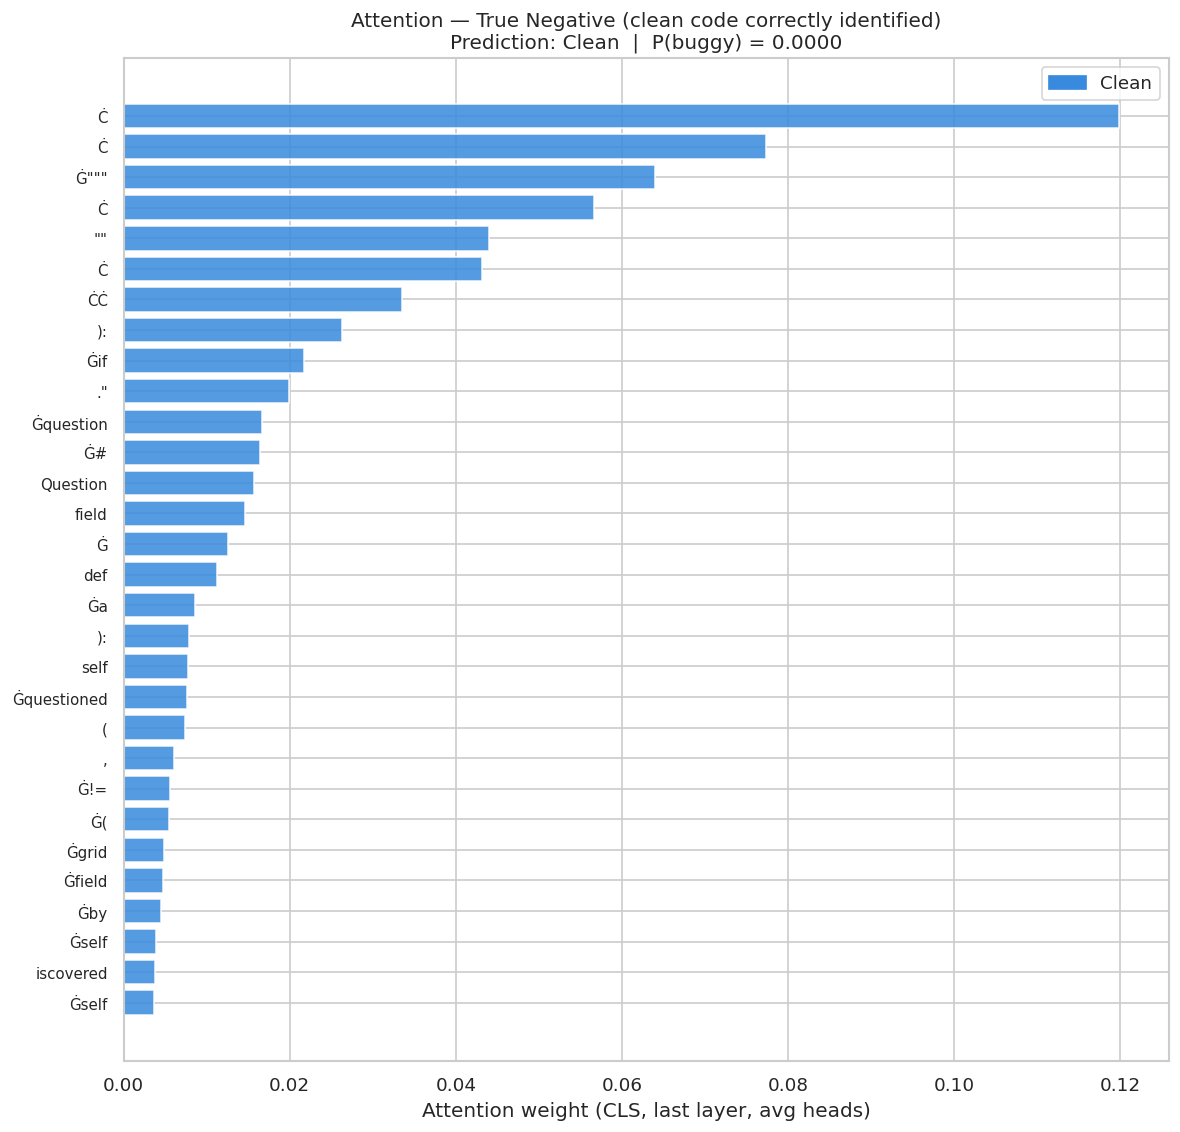

In [46]:
# Visualize attention for one TRUE NEGATIVE (clean correctly predicted as clean)

tn_idx = results_df[
    (results_df["true_label"] == 0) & (results_df["pred_label"] == 0)
].index[0]

code_sample = X_test[tn_idx]
tokens_weights, pred, prob = get_attention_weights(best_model, tokenizer, code_sample, DEVICE)

print(f"Sample index : {tn_idx}")
print(f"True label   : Clean (0)")
print(f"Prediction   : {'Buggy' if pred==1 else 'Clean'}")
print(f"P(buggy)     : {prob:.4f}")
print(f"\nCode (first 300 chars):\n{code_sample[:300]}")

plot_attention(
    tokens_weights, pred, prob,
    title="Attention — True Negative (clean code correctly identified)",
    save_path=os.path.join(CONFIG["FIGURES_DIR"], "16_attention_true_negative.png")
)

---
## Section 10: SHAP Explainability

SHAP (SHapley Additive exPlanations) assigns each token an importance score  
that shows how much it pushed the prediction toward **buggy** or **clean**.

- **Red tokens** -> pushed prediction toward buggy
- **Blue tokens** -> pushed prediction toward clean
- Unlike attention, SHAP values are theoretically grounded in game theory

We use a small sample (10–20 examples) because SHAP on transformers is slow  
even on GPU — each explanation requires hundreds of forward passes.

In [47]:
# Build a prediction function that SHAP can call
# SHAP passes raw text strings and expects probabilities back

def predict_proba(texts):
    """
    Takes a list of code strings, returns np.array of shape (n, 2)
    where column 0 = P(clean), column 1 = P(buggy).
    """
    all_probs = []
    best_model.eval()

    # Process in small batches to avoid OOM
    batch_size = 4
    for i in range(0, len(texts), batch_size):
        batch_texts = list(texts[i : i + batch_size])
        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            max_length=CONFIG["MAX_LENGTH"],
            truncation=True,
            padding="max_length"
        ).to(DEVICE)

        with torch.no_grad():
            outputs = best_model(
                input_ids      = inputs["input_ids"],
                attention_mask = inputs["attention_mask"]
            )
            probs = torch.softmax(outputs["logits"], dim=1).cpu().numpy()
        all_probs.append(probs)

    return np.vstack(all_probs)


print("predict_proba function defined.")
# Quick sanity check
test_out = predict_proba([X_test[0]])
print(f"Sample output shape: {test_out.shape}")
print(f"P(clean)={test_out[0,0]:.4f}, P(buggy)={test_out[0,1]:.4f}")

predict_proba function defined.
Sample output shape: (1, 2)
P(clean)=1.0000, P(buggy)=0.0000


In [48]:
# Build SHAP explainer using a small masker background sample
# This takes 2-5 minutes on T4 GPU

print("Building SHAP explainer...")
print("(This takes 2-5 minutes on GPU — please wait)\n")

# Use 20 background samples for the masker
background_texts = list(X_test[:20])

# TextMasker handles tokenization for SHAP
masker  = shap.maskers.Text(tokenizer=tokenizer)
explainer = shap.Explainer(predict_proba, masker, output_names=["Clean", "Buggy"])

print("SHAP explainer ready.")

Building SHAP explainer...
(This takes 2-5 minutes on GPU — please wait)

SHAP explainer ready.


In [49]:
# Compute SHAP values for 10 test samples
# Each explanation takes ~30-60 seconds on GPU

SHAP_SAMPLES = 10

print(f"Computing SHAP values for {SHAP_SAMPLES} samples...")
print("(~30-60 seconds per sample on T4 GPU)\n")

shap_texts = list(X_test[:SHAP_SAMPLES])
shap_values = explainer(shap_texts)

print(f"\nSHAP values computed.")
print(f"   shap_values shape: {shap_values.shape}")

Computing SHAP values for 10 samples...
(~30-60 seconds per sample on T4 GPU)



  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  10%|█         | 1/10 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  30%|███       | 3/10 [00:44<01:15, 10.73s/it]

...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 10/10 [03:26<00:00, 22.45s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 11it [03:47, 22.71s/it]


SHAP values computed.
   shap_values shape: (10, None, 2)


In [50]:
# Plot SHAP text plot for sample 0 — shows token-level contributions
# Red = pushed toward buggy, Blue = pushed toward clean

print("SHAP explanation — Sample 0")
print(f"True label : {'Buggy' if y_test[0]==1 else 'Clean'}")
print(f"P(buggy)   : {predict_proba([X_test[0]])[0,1]:.4f}\n")

# Class index 1 = Buggy
shap.plots.text(shap_values[0, :, 1])

SHAP explanation — Sample 0
True label : Clean
P(buggy)   : 0.0000



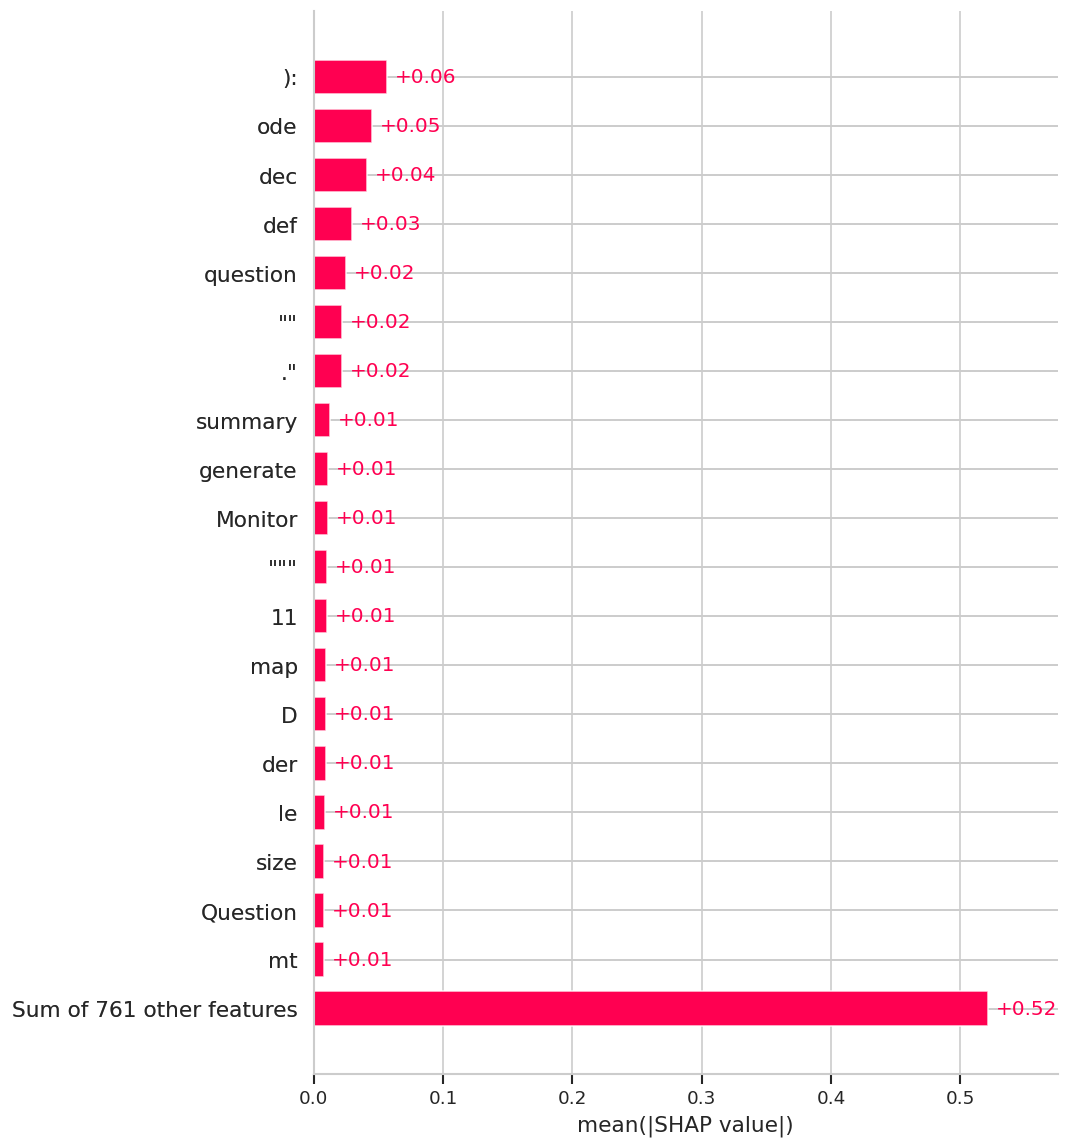

<Figure size 768x576 with 0 Axes>

Saved: 17_shap_bar.png


In [51]:
# Bar plot — mean absolute SHAP value per token across all samples
# Shows which tokens are most influential on average

shap.plots.bar(shap_values[:, :, 1], max_display=20, show=True)
plt.suptitle("Mean |SHAP| per token — class: Buggy", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["FIGURES_DIR"], "17_shap_bar.png"), bbox_inches="tight")
plt.show()
print("Saved: 17_shap_bar.png")

Waterfall — Buggy sample (index 1)


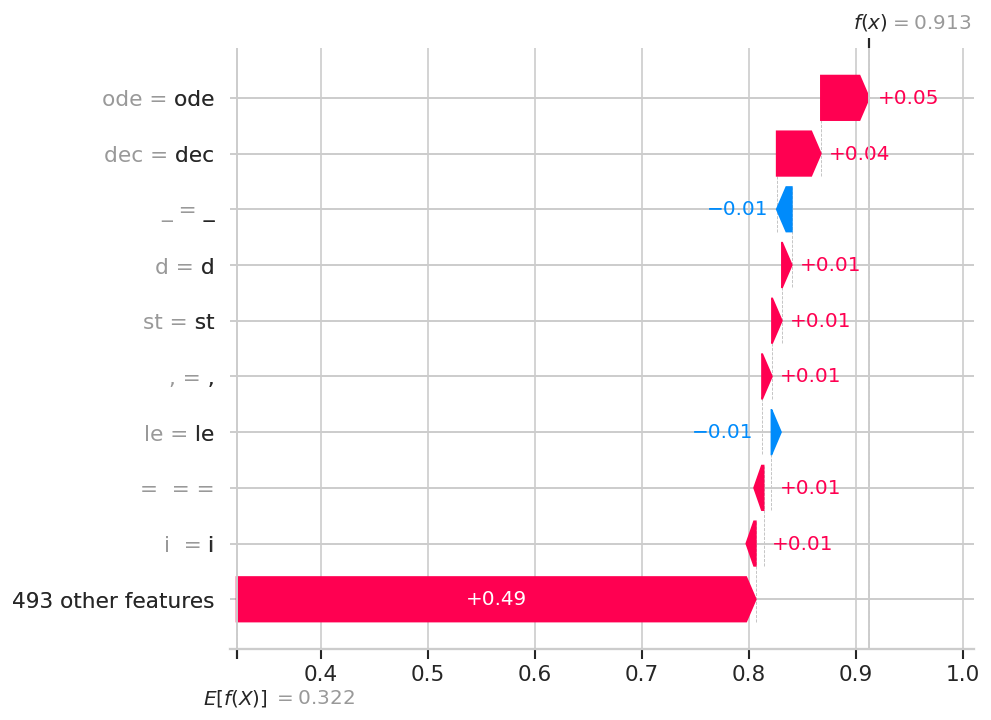

<Figure size 768x576 with 0 Axes>

Saved: 18_shap_waterfall_buggy.png

Waterfall — Clean sample (index 0)


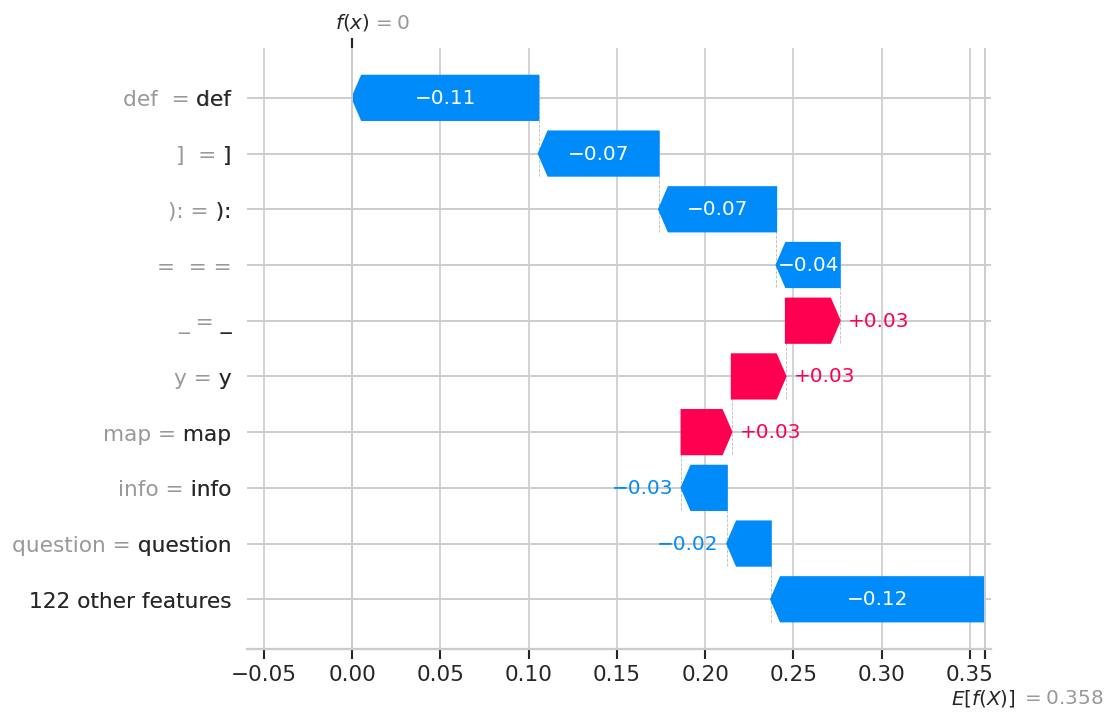

<Figure size 768x576 with 0 Axes>

Saved: 19_shap_waterfall_clean.png


In [52]:
# SHAP waterfall plot for one buggy and one clean sample

# Find first buggy and first clean sample in shap_texts
buggy_idxs = [i for i in range(SHAP_SAMPLES) if y_test[i] == 1]
clean_idxs = [i for i in range(SHAP_SAMPLES) if y_test[i] == 0]

if buggy_idxs:
    idx = buggy_idxs[0]
    print(f"Waterfall — Buggy sample (index {idx})")
    shap.plots.waterfall(shap_values[idx, :, 1])
    plt.savefig(os.path.join(CONFIG["FIGURES_DIR"], "18_shap_waterfall_buggy.png"), bbox_inches="tight")
    plt.show()
    print("Saved: 18_shap_waterfall_buggy.png")

if clean_idxs:
    idx = clean_idxs[0]
    print(f"\nWaterfall — Clean sample (index {idx})")
    shap.plots.waterfall(shap_values[idx, :, 1])
    plt.savefig(os.path.join(CONFIG["FIGURES_DIR"], "19_shap_waterfall_clean.png"), bbox_inches="tight")
    plt.show()
    print("Saved: 19_shap_waterfall_clean.png")

---
## Section 11: Per-Class Metrics Summary

Final summary table of all metrics broken down by class,  
suitable for copying directly into the project report.

In [53]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    test_metrics["all_labels"],
    test_metrics["all_preds"],
    target_names=["Clean", "Buggy"],
    output_dict=True
)

report_df = pd.DataFrame(report).T
report_df = report_df.round(4)

print("Per-class metrics:\n")
print(report_df.to_string())

# Save as CSV for the report
report_df.to_csv(os.path.join(CONFIG["REPORTS_DIR"], "classification_report.csv"))
print(f"\nSaved: classification_report.csv")

Per-class metrics:

              precision  recall  f1-score    support
Clean            0.9112  0.7089    0.7974  4256.0000
Buggy            0.5303  0.8263    0.6460  1693.0000
accuracy         0.7423  0.7423    0.7423     0.7423
macro avg        0.7208  0.7676    0.7217  5949.0000
weighted avg     0.8028  0.7423    0.7543  5949.0000

Saved: classification_report.csv


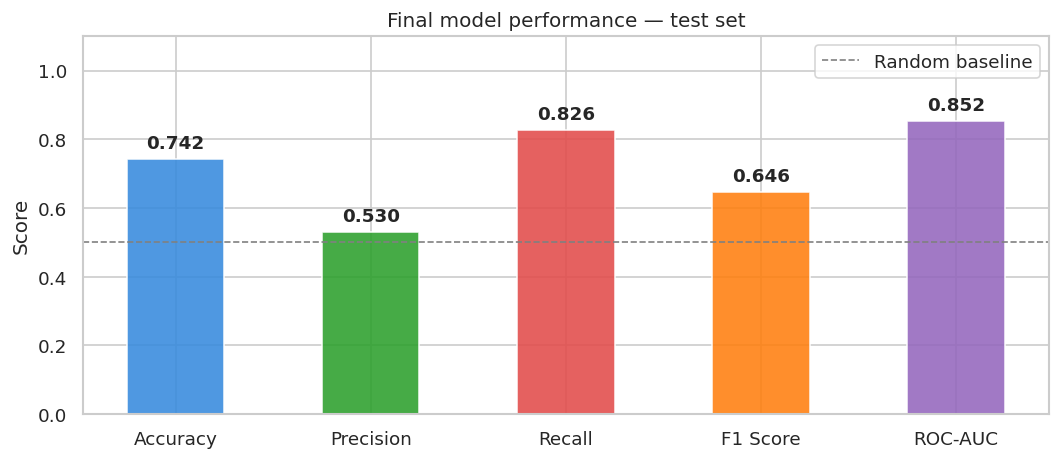

Saved: 20_final_metrics_summary.png


In [54]:
# Final summary bar chart — all key metrics in one view

metrics = {
    "Accuracy"  : test_metrics["accuracy"],
    "Precision" : test_metrics["precision"],
    "Recall"    : test_metrics["recall"],
    "F1 Score"  : test_metrics["f1"],
    "ROC-AUC"   : test_metrics["roc_auc"],
}

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(metrics.keys(), metrics.values(),
              color=["#378ADD", "#2CA02C", "#E24B4A", "#FF7F0E", "#9467BD"],
              width=0.5, alpha=0.88)

ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Final model performance — test set")
ax.axhline(0.5, color="gray", linestyle="--", lw=1, label="Random baseline")

for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["FIGURES_DIR"], "20_final_metrics_summary.png"), bbox_inches="tight")
plt.show()
print("Saved: 20_final_metrics_summary.png")

---
## Section 12: Save Everything & Final Summary

In [55]:
# Final inventory of all saved files

print("All figures saved to Drive:\n")
for f in sorted(os.listdir(CONFIG["FIGURES_DIR"])):
    path = os.path.join(CONFIG["FIGURES_DIR"], f)
    size_kb = os.path.getsize(path) / 1024
    print(f"   {f:<45} {size_kb:>7.1f} KB")

print("\nAll report files:\n")
for f in sorted(os.listdir(CONFIG["REPORTS_DIR"])):
    path = os.path.join(CONFIG["REPORTS_DIR"], f)
    if os.path.isfile(path):
        size_kb = os.path.getsize(path) / 1024
        print(f"   {f:<45} {size_kb:>7.1f} KB")

All figures saved to Drive:

   01_label_distribution.png                        44.7 KB
   02_samples_per_source.png                        18.3 KB
   03_code_length_distribution.png                  51.7 KB
   04_language_breakdown.png                        26.5 KB
   05_boxplot_code_length.png                       25.0 KB
   06_correlation_heatmap.png                       39.8 KB
   07_token_length_distribution.png                 32.9 KB
   08_token_distribution_splits.png                 39.8 KB
   09_class_balance_splits.png                      43.5 KB
   10_training_curves.png                           80.5 KB
   11_test_evaluation.png                          107.0 KB
   12_confidence_distribution.png                   54.0 KB
   13_error_analysis.png                            41.5 KB
   14_attention_true_positive.png                   63.0 KB
   15_attention_false_negative.png                  56.9 KB
   16_attention_true_negative.png                   64.3 KB
   17_shap_

In [57]:
print("""
═══════════════════════════════════════════════════════════
         NOTEBOOK 04 COMPLETE
         PROJECT COMPLETE
═══════════════════════════════════════════════════════════
""")

print("Final test set results:")
print(f"   Accuracy  : {test_metrics['accuracy']:.4f}  ({test_metrics['accuracy']*100:.1f}%)")
print(f"   Precision : {test_metrics['precision']:.4f}")
print(f"   Recall    : {test_metrics['recall']:.4f}")
print(f"   F1 Score  : {test_metrics['f1']:.4f}")
print(f"   ROC-AUC   : {test_metrics['roc_auc']:.4f}")

print(f"\nBest training epoch : {best_epoch}")
print(f"Best val F1         : {best_val_f1:.4f}")

print(f"\nFigures saved : {CONFIG['FIGURES_DIR']}")
print(f"Reports saved : {CONFIG['REPORTS_DIR']}")


═══════════════════════════════════════════════════════════
         NOTEBOOK 04 COMPLETE
         PROJECT COMPLETE 
═══════════════════════════════════════════════════════════

Final test set results:
   Accuracy  : 0.7423  (74.2%)
   Precision : 0.5303
   Recall    : 0.8263
   F1 Score  : 0.6460
   ROC-AUC   : 0.8519

Best training epoch : 3
Best val F1         : 0.6572

Figures saved : /content/drive/MyDrive/code_review_project/reports/figures/
Reports saved : /content/drive/MyDrive/code_review_project/reports/
